# AgriSoil ML Module
**Inputs:** N, P, K, Humidity, pH
**Output:** Crop recommendation → product recommendation

Dataset: Kaggle crop recommendation dataset (20,000 rows)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

## 1. Load & Explore Dataset

In [2]:
df = pd.read_csv('soil_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (20000, 10)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet


In [3]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     20000 non-null  float64
 1   Phosphorus   20000 non-null  float64
 2   Potassium    20000 non-null  float64
 3   Temperature  20000 non-null  float64
 4   Humidity     20000 non-null  float64
 5   pH_Value     20000 non-null  float64
 6   Rainfall     20000 non-null  float64
 7   Crop         20000 non-null  str    
 8   Soil_Type    20000 non-null  str    
 9   Variety      20000 non-null  str    
dtypes: float64(7), str(3)
memory usage: 1.9 MB

Missing values:
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
Soil_Type      0
Variety        0
dtype: int64


In [4]:
df[['Nitrogen','Phosphorus','Potassium','Humidity','pH_Value']].describe()

,Nitrogen,Phosphorus,Potassium,Humidity,pH_Value
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,77.216965,47.482070,55.162956,64.897753,6.496126
std,41.857663,24.587506,25.969091,20.200687,1.155750
min,5.006013,5.000483,10.000672,30.002297,4.500082
25%,40.459715,26.225044,32.641905,47.462026,5.497988
50%,77.573159,47.469579,55.248133,64.776613,6.493812
75%,113.055595,68.625556,77.690183,82.310482,7.501771
max,149.998785,89.999086,99.996480,99.992346,8.499914


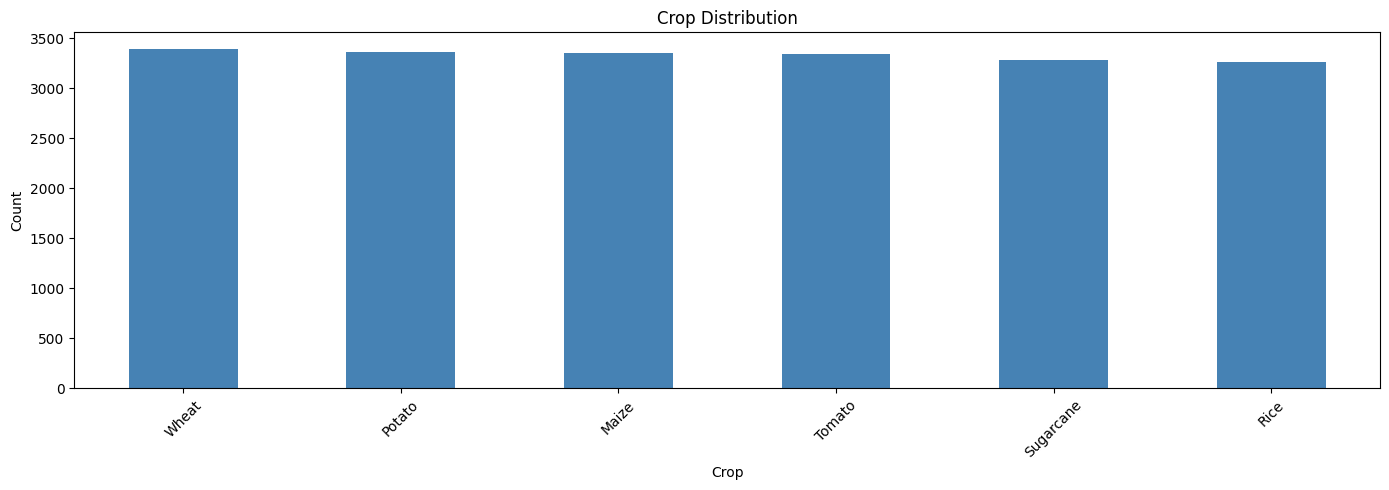

In [5]:
plt.figure(figsize=(14, 5))
df['Crop'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Feature Selection
We use only the 5 values the ESP32 sends: **N, P, K, Humidity, pH**

In [6]:
X = df[['Nitrogen', 'Phosphorus', 'Potassium', 'Humidity', 'pH_Value']]
y = df['Crop']

print(f'Features: {list(X.columns)}')
print(f'Classes: {y.nunique()} crops')
print(y.value_counts())

Features: ['Nitrogen', 'Phosphorus', 'Potassium', 'Humidity', 'pH_Value']
Classes: 6 crops
Crop
Wheat        3390
Potato       3362
Maize        3352
Tomato       3344
Sugarcane    3284
Rice         3268
Name: count, dtype: int64


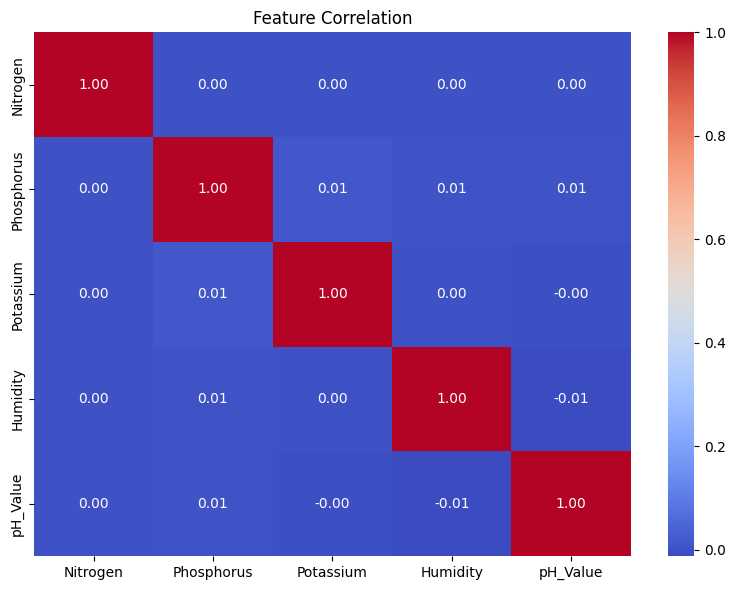

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

## 3. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} rows')
print(f'Test:  {X_test.shape[0]} rows')

Train: 16000 rows
Test:  4000 rows


## 4. Decision Tree

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print(f'Decision Tree Accuracy: {accuracy_score(y_test, dt_pred) * 100:.1f}%')
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 15.8%
              precision    recall  f1-score   support

       Maize       0.17      0.16      0.16       679
      Potato       0.16      0.16      0.16       675
        Rice       0.14      0.15      0.14       641
   Sugarcane       0.14      0.16      0.15       616
      Tomato       0.16      0.15      0.15       677
       Wheat       0.19      0.17      0.18       712

    accuracy                           0.16      4000
   macro avg       0.16      0.16      0.16      4000
weighted avg       0.16      0.16      0.16      4000



## 5. Random Forest

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred) * 100:.1f}%')
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 16.8%
              precision    recall  f1-score   support

       Maize       0.15      0.15      0.15       679
      Potato       0.17      0.18      0.18       675
        Rice       0.16      0.17      0.16       641
   Sugarcane       0.17      0.17      0.17       616
      Tomato       0.19      0.18      0.19       677
       Wheat       0.17      0.15      0.16       712

    accuracy                           0.17      4000
   macro avg       0.17      0.17      0.17      4000
weighted avg       0.17      0.17      0.17      4000



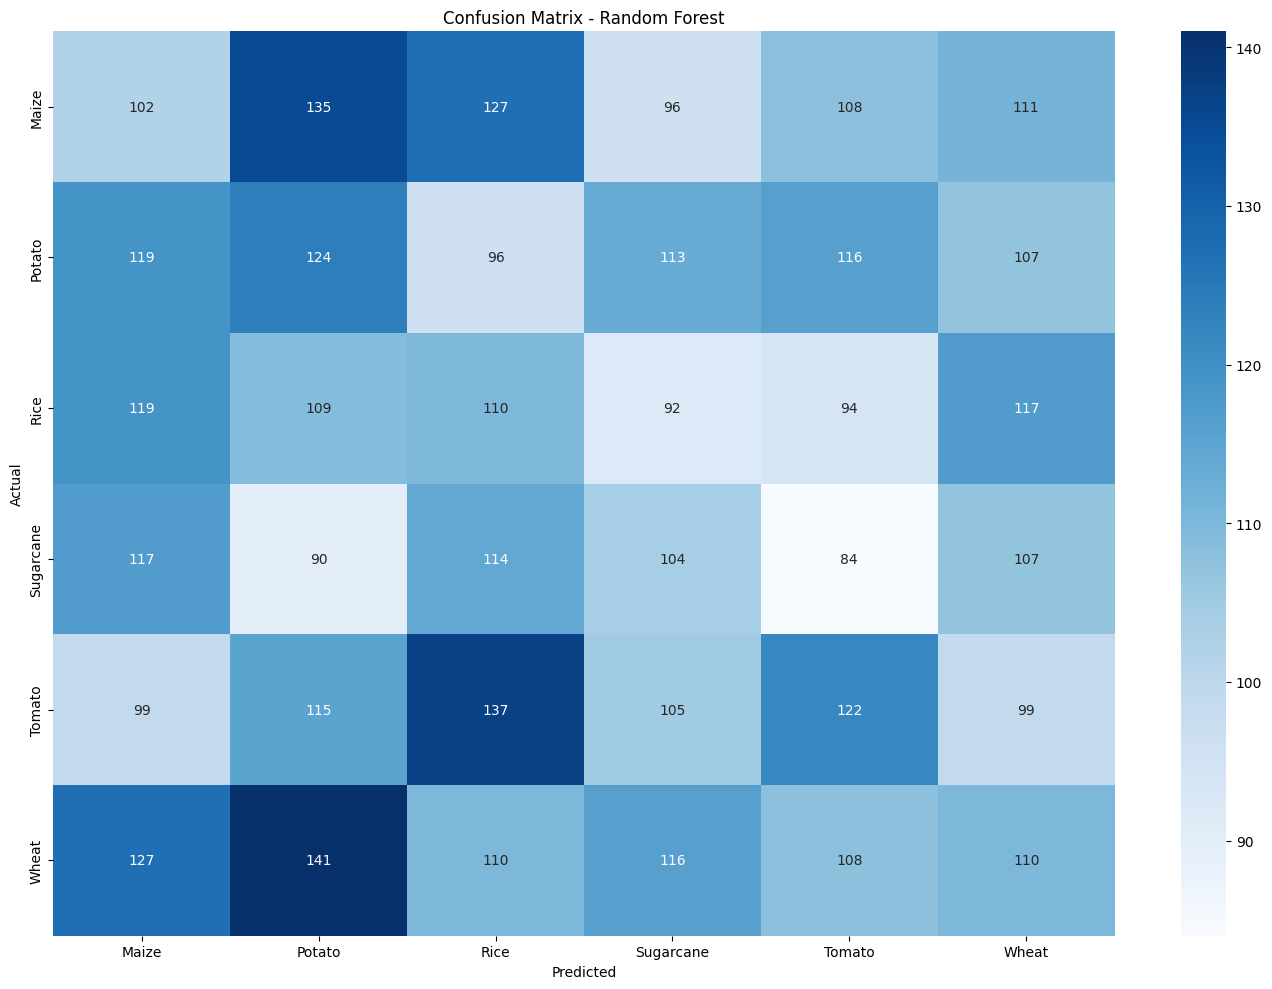

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

## 6. Feature Importance

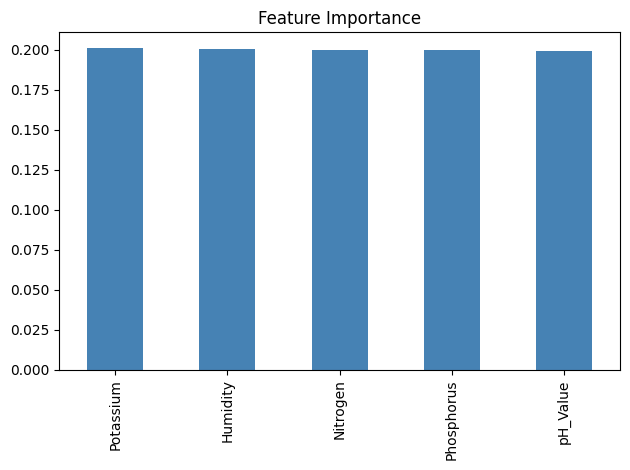

Potassium     0.200794
Humidity      0.200371
Nitrogen      0.199886
Phosphorus    0.199807
pH_Value      0.199143
dtype: float64


In [12]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()
print(importances)

## 7. Save Model

In [13]:
joblib.dump(rf_model, 'soil_model.pkl')
print('Model saved to soil_model.pkl')

Model saved to soil_model.pkl


## 8. Test with ESP32 Data

In [ ]:
print('\n===== TEST DU SOL =====')

while True:
    try:
        N = float(input('Entrer N (azote) : '))
        P = float(input('Entrer P (phosphore) : '))
        K = float(input('Entrer K (potassium) : '))
        H = float(input('Entrer Humidity (humidite) : '))
        pH = float(input('Entrer pH : '))

        sample = pd.DataFrame([[N, P, K, H, pH]], columns=['Nitrogen', 'Phosphorus', 'Potassium', 'Humidity', 'pH_Value'])
        prediction = rf_model.predict(sample)[0]
        print(f'\n Résultat : {prediction}')

    except:
        print('Erreur de saisie')
        break

   


===== TEST DU SOL =====


Entrer N (azote) :  90
Entrer P (phosphore) :  42
Entrer K (potassium) :  43
Entrer Humidity (humidite) :  82
Entrer pH :  6.5



 Résultat : Wheat


Entrer N (azote) :  77
Entrer P (phosphore) :  48
Entrer K (potassium) :  22
Entrer Humidity (humidite) :  65
Entrer pH :  6.2



 Résultat : Tomato


Entrer N (azote) :  101
Entrer P (phosphore) :  28
Entrer K (potassium) :  30
Entrer Humidity (humidite) :  58
Entrer pH :  6.8



 Résultat : Rice
